# Visualizing What CNNs Learn

**COMP 395 — Deep Learning**

This notebook walks through how to visualize what a trained CNN has learned. We'll use a model trained on **FashionMNIST** as a worked example, then you'll adapt the same techniques to your MNIST model in Lab 5.

By the end, you'll know how to:
1. Extract and display learned convolutional filters
2. Pass an image through a model layer-by-layer and visualize intermediate feature maps
3. Interpret what these visualizations tell you about the model

---

## Setup: A Trained Model to Work With

First, we need a trained CNN. We'll quickly train one on FashionMNIST — it has the same shape as MNIST (1×28×28 grayscale) but classifies clothing items instead of digits. This keeps the example separate from your Lab 5 work.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Load FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),  # FashionMNIST stats
])

fashion_train = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
fashion_test = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(fashion_train, batch_size=64, shuffle=True)
test_loader = DataLoader(fashion_test, batch_size=64, shuffle=False)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training: {len(fashion_train)} images")
print(f"Test:     {len(fashion_test)} images")

100.0%
100.0%
100.0%
100.0%

Training: 60000 images
Test:     10000 images


In [2]:
# A simple CNN — same structure as SimpleCNN from Day 2
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = FashionCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train for 5 epochs (should reach ~88-90% accuracy)
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # Quick test accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/5  Loss: {avg_loss:.4f}  Test Acc: {correct/total:.4f}")

print("\nDone! We now have a trained model to visualize.")

Epoch 1/5  Loss: 0.4501  Test Acc: 0.8674
Epoch 2/5  Loss: 0.2959  Test Acc: 0.8841
Epoch 3/5  Loss: 0.2520  Test Acc: 0.9013
Epoch 4/5  Loss: 0.2219  Test Acc: 0.9095
Epoch 5/5  Loss: 0.1981  Test Acc: 0.9137

Done! We now have a trained model to visualize.


---

## Part 1: Visualizing Learned Filters

The weights of the first convolutional layer are directly interpretable. Each filter is a small image that the network has learned to look for.

### Where do the weights live?

Every `nn.Conv2d` layer stores its weights in `.weight.data`. Let's look at the shape:

In [3]:
# Inspect the shape of conv1 weights
weights = model.conv1.weight.data

print(f"conv1 weight shape: {weights.shape}")
print()

# Unpack the dimensions
out_ch, in_ch, kH, kW = weights.shape
print(f"  out_channels = {out_ch}  (number of filters)")
print(f"  in_channels  = {in_ch}   (channels per filter — 1 for grayscale)")
print(f"  kernel_size  = ({kH}, {kW})")
print()
print(f"So we have {out_ch} filters, each of size {in_ch}×{kH}×{kW}.")
print(f"Since in_channels=1, each filter is just a {kH}×{kW} 2D image.")

conv1 weight shape: torch.Size([16, 1, 3, 3])

  out_channels = 16  (number of filters)
  in_channels  = 1   (channels per filter — 1 for grayscale)
  kernel_size  = (3, 3)

So we have 16 filters, each of size 1×3×3.
Since in_channels=1, each filter is just a 3×3 2D image.


### Displaying the filters

Each filter is a small 3×3 grayscale image. We can display them in a grid:

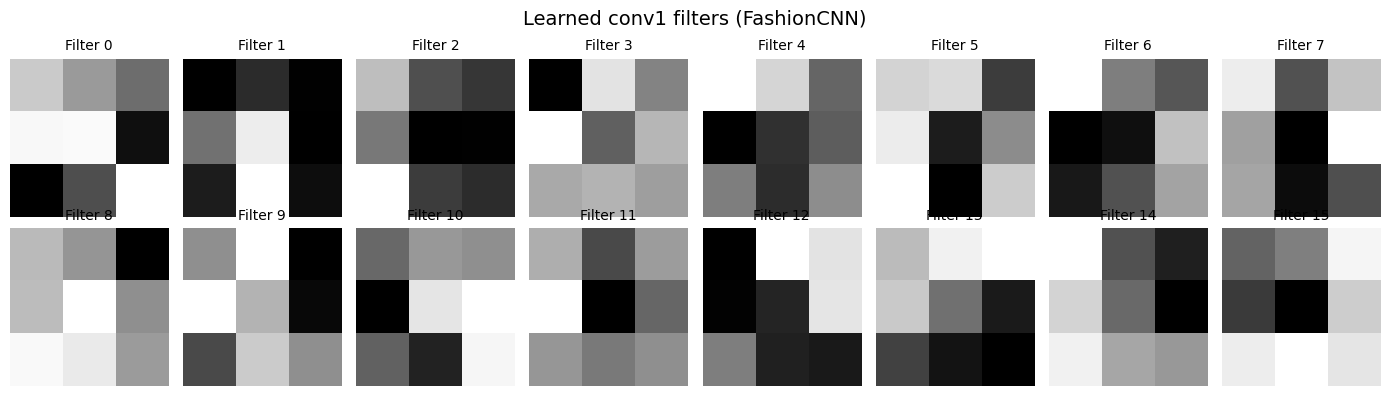

Filter 0 values:
[[ 0.185  0.028 -0.122]
 [ 0.335  0.343 -0.43 ]
 [-0.481 -0.223  0.36 ]]

Filter 1 values:
[[-0.272 -0.194 -0.27 ]
 [-0.07   0.15  -0.27 ]
 [-0.221  0.183 -0.248]]


In [4]:
# Plot all 16 conv1 filters
weights = model.conv1.weight.data.cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        # weights[i] has shape (1, 3, 3) — squeeze out the channel dim
        filt = weights[i].squeeze().numpy()
        ax.imshow(filt, cmap='gray')
        ax.set_title(f"Filter {i}", fontsize=10)
    ax.axis('off')

plt.suptitle("Learned conv1 filters (FashionCNN)", fontsize=14)
plt.tight_layout()
plt.show()

# Also print the raw values of a few filters
print("Filter 0 values:")
print(weights[0].squeeze().numpy().round(3))
print()
print("Filter 1 values:")
print(weights[1].squeeze().numpy().round(3))

### What to look for

- **Edge-like patterns:** filters with positive values on one side and negative on the other detect edges (like the Sobel kernels from Day 1).
- **Blob detectors:** filters with a bright center and dark surround (or vice versa) detect spots or corners.
- **Variety:** a well-trained network should have filters that look different from each other. If they all look the same, the network is wasting capacity.

### What about conv2?

The second layer's filters are harder to interpret directly because each filter has shape `(16, 3, 3)` — it operates across 16 input channels, not a single grayscale image. You can still display the individual channel slices, but they don't correspond to anything as intuitive as "the raw image." This is why we visualize **feature maps** instead for deeper layers.

---

## Part 2: Visualizing Intermediate Feature Maps

Instead of looking at the weights directly, we can pass an image through the network and see what each layer *does* to it. The output of a convolutional layer is a stack of feature maps — one per filter.

### The idea

```
Input image (1, 28, 28)
        │
   conv1 + relu
        │
   16 feature maps (16, 28, 28)  ← what does each filter respond to?
        │
   max pooling
        │
   16 feature maps (16, 14, 14)
        │
   conv2 + relu
        │
   32 feature maps (32, 14, 14)  ← higher-level patterns
        ...
```

We'll pick a single test image and run it through layer by layer.

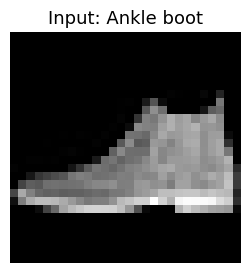

Input tensor shape: torch.Size([1, 28, 28])


In [5]:
# Grab a test image
test_images, test_labels = next(iter(test_loader))
sample_img = test_images[0]   # shape: (1, 28, 28)
sample_label = test_labels[0]

# Show the original image
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(sample_img.squeeze().numpy(), cmap='gray')
ax.set_title(f"Input: {class_names[sample_label.item()]}", fontsize=13)
ax.axis('off')
plt.show()

print(f"Input tensor shape: {sample_img.shape}")

### Running through the model layer by layer

The key technique: instead of calling `model(x)` which runs the whole forward pass, we call each layer individually and save the intermediate results.

Note that we add a batch dimension with `unsqueeze(0)` because `nn.Conv2d` expects input shape `(N, C, H, W)`, not `(C, H, W)`.

In [6]:
model.eval()

# Add batch dimension: (1, 28, 28) -> (1, 1, 28, 28)
x = sample_img.unsqueeze(0)
print(f"Input:           {x.shape}")

# Layer by layer
after_conv1 = model.conv1(x)
print(f"After conv1:     {after_conv1.shape}")

after_relu1 = model.relu(after_conv1)
print(f"After relu:      {after_relu1.shape}")

after_pool1 = model.pool(after_relu1)
print(f"After pool1:     {after_pool1.shape}")

after_conv2 = model.conv2(after_pool1)
print(f"After conv2:     {after_conv2.shape}")

after_relu2 = model.relu(after_conv2)
print(f"After relu2:     {after_relu2.shape}")

after_pool2 = model.pool(after_relu2)
print(f"After pool2:     {after_pool2.shape}")

Input:           torch.Size([1, 1, 28, 28])
After conv1:     torch.Size([1, 16, 28, 28])
After relu:      torch.Size([1, 16, 28, 28])
After pool1:     torch.Size([1, 16, 14, 14])
After conv2:     torch.Size([1, 32, 14, 14])
After relu2:     torch.Size([1, 32, 14, 14])
After pool2:     torch.Size([1, 32, 7, 7])


### Displaying feature maps after conv1

`after_relu1` has shape `(1, 16, 28, 28)` — that's 16 feature maps, each 28×28. Let's display them all:

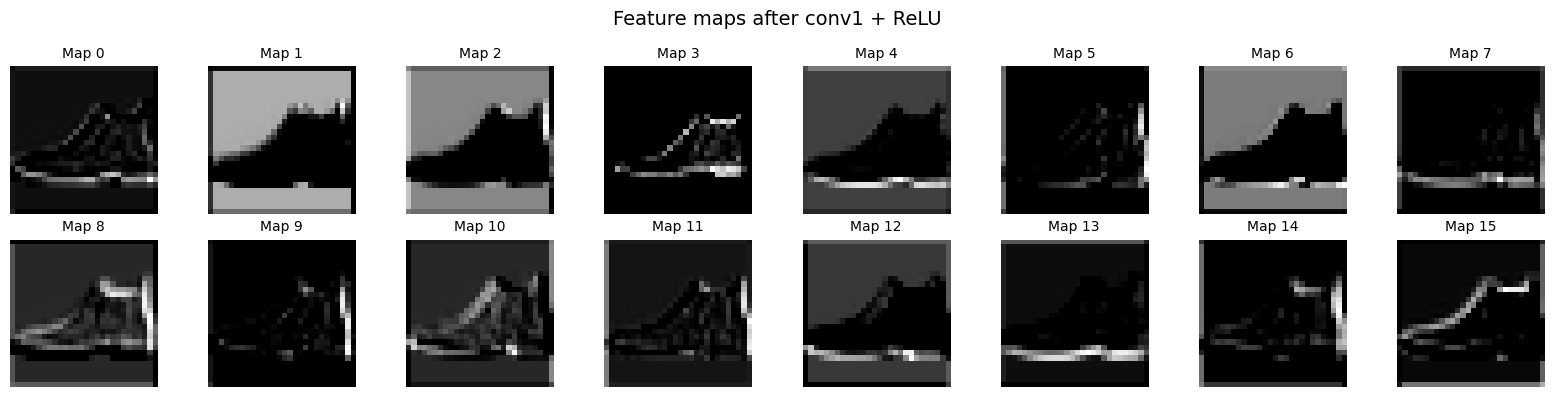

In [7]:
# Visualize all 16 feature maps after conv1 + relu
feature_maps = after_relu1.squeeze().detach().numpy()  # (16, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[0]:
        ax.imshow(feature_maps[i], cmap='gray')
        ax.set_title(f"Map {i}", fontsize=10)
    ax.axis('off')

plt.suptitle("Feature maps after conv1 + ReLU", fontsize=14)
plt.tight_layout()
plt.show()

### What to look for

- **Different maps highlight different features.** Some might respond to horizontal edges, others to vertical edges, others to corners or textures.
- **ReLU zeros out negatives.** Black regions in the feature maps are where the filter produced a negative response (set to 0 by ReLU). Bright regions are where the filter found what it's looking for.
- **Compare to the filters.** Filter 0's weights determine what feature map 0 looks like. An edge-detecting filter produces feature maps that highlight edges.

### Feature maps after conv2

These are more abstract — they combine patterns from the first layer:

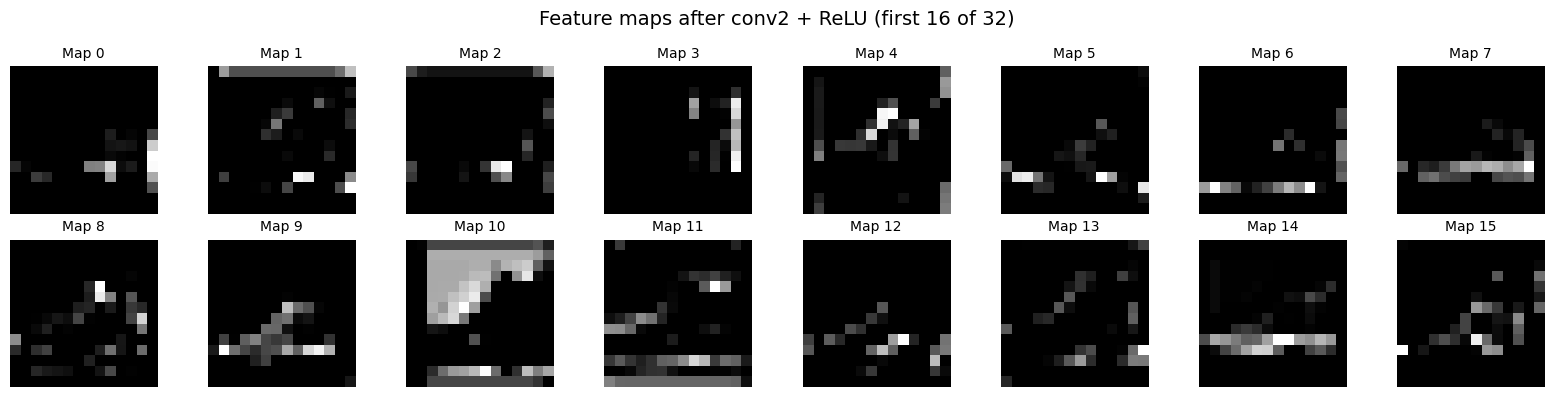

In [8]:
# Visualize 16 of the 32 feature maps after conv2 + relu
feature_maps2 = after_relu2.squeeze().detach().numpy()  # (32, 14, 14)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < 16:  # show first 16 of 32
        ax.imshow(feature_maps2[i], cmap='gray')
        ax.set_title(f"Map {i}", fontsize=10)
    ax.axis('off')

plt.suptitle("Feature maps after conv2 + ReLU (first 16 of 32)", fontsize=14)
plt.tight_layout()
plt.show()

Notice how these are:
- **Smaller** (14×14 instead of 28×28) — pooling halved the spatial dimensions.
- **More abstract** — they don't look like simple edges anymore. They respond to combinations of the features from layer 1.

This is the **hierarchical feature learning** that LeCun et al. describe in the paper: early layers detect simple features (edges, textures), deeper layers compose them into more complex patterns (parts of objects, shapes).

### Side-by-side: input → conv1 → conv2

A useful summary view puts the original image next to selected feature maps from each layer:

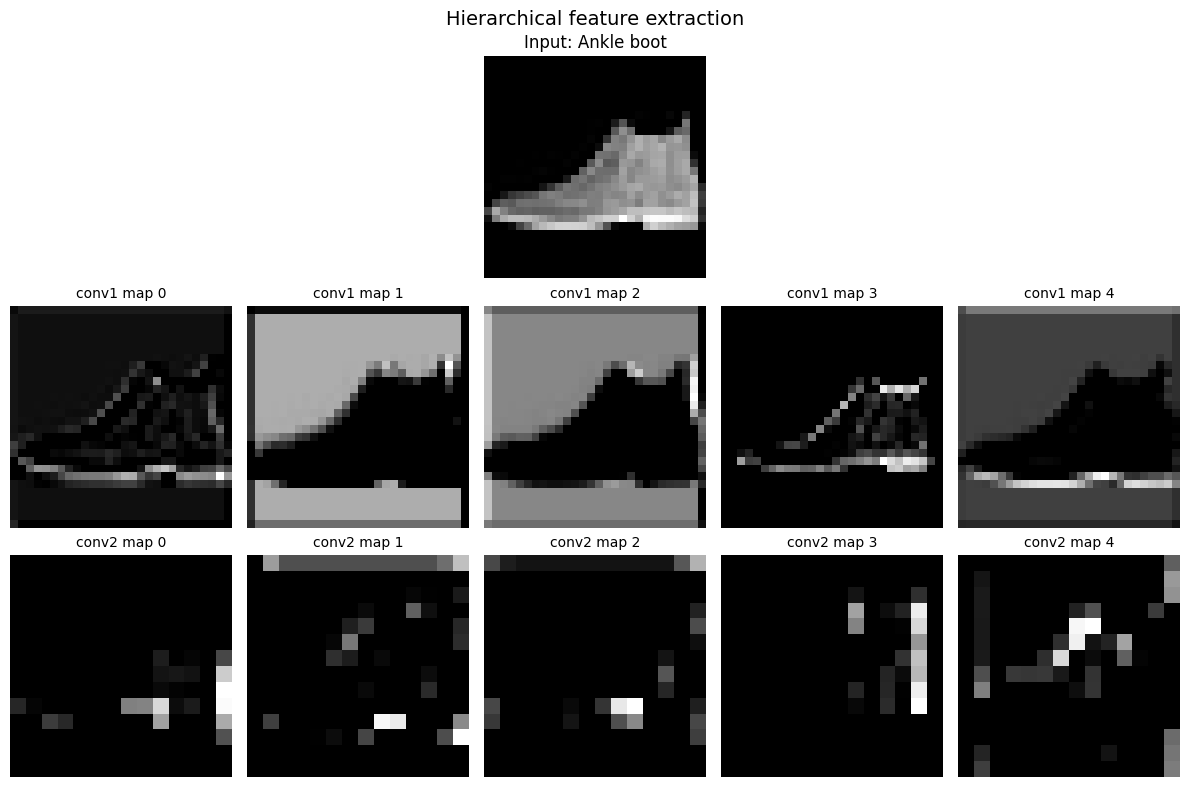

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

# Row 0: original image (centered)
for ax in axes[0]:
    ax.axis('off')
axes[0][2].imshow(sample_img.squeeze().numpy(), cmap='gray')
axes[0][2].set_title(f"Input: {class_names[sample_label.item()]}", fontsize=12)

# Row 1: 5 feature maps from conv1
maps1 = after_relu1.squeeze().detach().numpy()
for i in range(5):
    axes[1][i].imshow(maps1[i], cmap='gray')
    axes[1][i].set_title(f"conv1 map {i}", fontsize=10)
    axes[1][i].axis('off')

# Row 2: 5 feature maps from conv2
maps2 = after_relu2.squeeze().detach().numpy()
for i in range(5):
    axes[2][i].imshow(maps2[i], cmap='gray')
    axes[2][i].set_title(f"conv2 map {i}", fontsize=10)
    axes[2][i].axis('off')

plt.suptitle("Hierarchical feature extraction", fontsize=14)
plt.tight_layout()
plt.show()

---

## Your Turn: Visualize Your MNIST Model

Now adapt these techniques to your trained MNIST CNN from Lab 5. The code is almost identical — here's what changes and what stays the same.

### Visualizing conv1 filters

**What stays the same:** the weight extraction and plotting code.

**What changes:** the model variable name and the class names for labeling.

**Hints:**
- Your MNIST model's first conv layer is probably also called `conv1`. If not, check your model definition.
- `model.conv1.weight.data` gives you the weights regardless of what you named the model variable — just use whatever variable holds your trained model.
- If your first conv layer has a different number of filters (e.g., 32 instead of 16), adjust the subplot grid accordingly. A quick way: `n = model.conv1.weight.shape[0]` then `plt.subplots(n // 8, 8)`.

### Visualizing feature maps

**What stays the same:** the layer-by-layer execution pattern and the plotting code.

**What changes:** your model might have different layer names, different numbers of layers, or additional layers like batch norm or dropout.

**Hints:**
- Run through your `forward` method line by line. If your forward looks like:
  ```python
  x = self.pool(self.relu(self.conv1(x)))
  x = self.pool(self.relu(self.conv2(x)))
  ```
  then break it apart the same way we did above — call each operation separately and save the intermediate result.
- If you added `BatchNorm2d`, include it in the sequence: `x = model.bn1(model.conv1(x))` then `x = model.relu(x)`.
- Remember to call `model.eval()` before visualizing. This matters if you have dropout or batch norm, which behave differently in eval mode.
- Use `detach().numpy()` to convert tensors to numpy arrays for plotting. If your model is on GPU, add `.cpu()` first: `.cpu().detach().numpy()`.

### Questions to answer in your Lab 5 writeup

1. Do any of your learned conv1 filters resemble the handcrafted kernels from Day 1 (horizontal edges, vertical edges, Sobel)?
2. Pick a digit image and show its feature maps. Which filters activate most strongly? Does that make sense given the digit's shape?
3. Try the same visualization on a digit your model gets wrong. Do the feature maps look different from a correctly classified example? How?

In [ ]:
# Space for your MNIST visualization work
# Load your trained model and adapt the code from above


